We are experimenting to see whether we can infer significant information about the signatures from noisy samples (ie samples containing two cell types in known proportions but such that you do not know which reads belong to which cell type).

In [3]:
from itertools import product

import numpy as np
import cvxpy as cp
import matplotlib.pyplot as plt
import pandas as pd
from tqdm.notebook import tqdm

## Functions

In [6]:
# utilities to manipulate signatures as binary vectors and convert them to indices for easier handling
def get_idx_from_sig(sig):
    idx = 0
    for i, bit in enumerate(sig):
        idx += bit * (2**i)
    return idx


def get_sig_from_idx(idx, sig_length):
    assert idx < 2**sig_length, "Index is too large for the given signature length"
    sig = []
    for i in range(sig_length):
        bit = (idx // (2**i)) % 2
        sig.append(bit)
    return np.array(sig)

In [20]:
# EM construction of generalized soft labels
def em_soft_labels(
    signature_counts_per_sample,
    ctype_prop_per_sample,
    max_iterations=10,
    delta=None,
    verbose=False,
):
    """
    WARNING: this is a very naive implementation of EM for demonstration purposes only.
    It is not optimized for speed or memory efficiency, and should not be used for large datasets without further optimization.

    Args:
        signature_counts_per_sample: (n_samples, n_signatures)
        ctype_prop_per_sample: (n_samples, n_ctypes)
        max_iterations: maximum number of EM iterations
        delta: convergence threshold (optional)
        verbose: whether to print convergence information
    """
    n_samples, n_signatures = signature_counts_per_sample.shape
    _, n_ctypes = ctype_prop_per_sample.shape

    # Initialize P(signature | ctype) so the loop can start with an E-step.
    sig_prob_per_ctype = np.ones((n_ctypes, n_signatures), dtype=float) / n_signatures
    sig_prob_per_ctype_history = []

    for iteration in range(max_iterations):
        # E-step: responsibilities for each (sample, signature) group.
        # All reads sharing the same sample and signature get the same responsibility.
        ctype_prob_per_group = (
            ctype_prop_per_sample[:, np.newaxis, :]
            * sig_prob_per_ctype.T[np.newaxis, :, :]
        )  # (n_samples, n_signatures, n_ctypes)
        normalizer = ctype_prob_per_group.sum(axis=2, keepdims=True)
        ctype_prob_per_group = np.divide(
            ctype_prob_per_group,
            normalizer,
            out=np.ones_like(ctype_prob_per_group) / n_ctypes,
            where=normalizer > 0,
        )

        # M-step: weighted pseudo-counts and update P(signature | ctype).
        pseudo_counts_of_sig_per_ctype = (
            signature_counts_per_sample[:, :, np.newaxis] * ctype_prob_per_group
        ).sum(axis=0).T  # (n_ctypes, n_signatures)
        denom = pseudo_counts_of_sig_per_ctype.sum(axis=1, keepdims=True)
        new_sig_prob_per_ctype = np.divide(
            pseudo_counts_of_sig_per_ctype,
            denom,
            out=np.zeros_like(pseudo_counts_of_sig_per_ctype),
            where=denom > 0,
        )

        sig_prob_per_ctype_history.append(new_sig_prob_per_ctype.copy())

        # check for convergence on successive M-step updates
        change = np.abs(new_sig_prob_per_ctype - sig_prob_per_ctype).max()
        sig_prob_per_ctype = new_sig_prob_per_ctype
        if delta is not None and change < delta:
            if verbose:
                print(f"Converged at iteration {iteration} with change {change:.6f}")
            break

    return sig_prob_per_ctype, np.array(sig_prob_per_ctype_history)

In [8]:
def em_sl_with_archetypes(
    signature_counts_per_sample: np.ndarray,
    ctype_prop_per_sample: np.ndarray,
    n_archetypes: int,
    n_cpgs: int,
    max_iterations: int = 10,
    reestimate_ctype_prop_per_sample: bool = False,
    delta: float = None,
    verbose: bool = False,
    return_llh: bool = False,
    archetype_methylation_init_config: dict = None,
):
    """
    WARNING: this is a very naive implementation of the EM algorithm
    for estimation of soft labels from noisy samples using underlying methylation archetypes
    for demonstration purposes only.

    Here, we assume that all signatures cover all CpGs.

    All reads having the same biological sample and the same signature will have
    the same updates, they are thus treated as a single read for the purpose
    of the update of their parameters.

    """
    n_samples, n_signatures = signature_counts_per_sample.shape
    assert 2**n_cpgs == n_signatures, "Number of signatures must be 2^n_cpgs"
    _, n_ctypes = ctype_prop_per_sample.shape

    if archetype_methylation_init_config is None:
        archetype_methylation_init_config = {
            "type": "random",
        }

    ## Initialize the parameters
    # Ctype proba per sample
    ctype_prob_per_sample = ctype_prop_per_sample.copy()  # (n_samples, n_ctypes)
    # Initialize archetype probabilities per ctype uniformly
    archetype_prob_per_ctype = np.ones((n_ctypes, n_archetypes)) / n_archetypes
    # Initialize methylation probabilities per archetype
    if archetype_methylation_init_config["type"] == "random":
        methylation_prob_per_archetype = np.random.rand(
            n_archetypes, n_cpgs
        )  # (n_archetypes, n_cpgs)
    elif archetype_methylation_init_config["type"] == "linear":
        # each archetype has a fixed methylation level, linearly spaced between 0.05 and 0.95
        # For 3 archetypes, this would be [0.05, 0.5, 0.95]
        levels = np.linspace(0.05, 0.95, n_archetypes)
        methylation_prob_per_archetype = np.tile(levels[:, np.newaxis], (1, n_cpgs))
    else:
        raise ValueError(f"Unknown archetype methylation init type: {archetype_methylation_init_config['type']}")
    # Initialize joint (ctype, archetype) probabilities per read
    archetype_prob_per_read = np.ones(
        (n_samples, n_signatures, n_ctypes, n_archetypes)
    ) / (n_ctypes * n_archetypes)

    # Precompute the binary signature of each signature index (n_signatures, n_cpgs)
    sig_matrix = np.array([get_sig_from_idx(s, n_cpgs) for s in range(n_signatures)])

    methylation_prob_per_archetype_history = []

    for iteration in range(max_iterations):
        # E-step: compute the probabilities of each read belonging to each (ctype, archetype) pair
        for s in range(n_signatures):
            # Compute the probability of the signature given each archetype (depends only on s)
            sig = sig_matrix[s]  # (n_cpgs,)
            prob_sig_given_archetype = np.prod(
                methylation_prob_per_archetype**sig
                * (1 - methylation_prob_per_archetype) ** (1 - sig),
                axis=1,
            )  # (n_archetypes,)
            for i in range(n_samples):
                # Compute the joint probability of (ctype, archetype) given the signature and sample
                joint_prob = (
                    ctype_prob_per_sample[i, :, np.newaxis]  # (n_ctypes, 1)
                    * archetype_prob_per_ctype[:, :]  # (n_ctypes, n_archetypes)
                    * prob_sig_given_archetype[np.newaxis, :]  # (1, n_archetypes)
                )  # (n_ctypes, n_archetypes)
                # laplace smoothing to avoid zero probabilities
                joint_prob += 1e-10
                joint_prob /= joint_prob.sum()  # Normalize to get probabilities
                archetype_prob_per_read[i, s, :, :] = joint_prob

        # form the expected complete-data counts
        # weight each (sample, signature) responsibility by its observed read count, so that all
        # reads sharing the same (sample, signature) are treated together
        weighted_gamma = (
            signature_counts_per_sample[:, :, np.newaxis, np.newaxis]
            * archetype_prob_per_read
        )  # (n_samples, n_signatures, n_ctypes, n_archetypes)

        # n_tilde[b, c] = sum_{i: b_i = b} gamma_i(c)
        n_tilde = weighted_gamma.sum(axis=(1, 3))  # (n_samples, n_ctypes)
        # m_tilde[c, a] = sum_i gamma_i(c, a)
        m_tilde = weighted_gamma.sum(axis=(0, 1))  # (n_ctypes, n_archetypes)

        # gamma_i(a) aggregated per (signature, archetype) across all samples
        # (all signatures cover all CpGs here, so coverage is total)
        mass_per_sig_archetype = weighted_gamma.sum(
            axis=(0, 2)
        )  # (n_signatures, n_archetypes)
        # o1[a, k] = sum_{i: k in dom(s_i)} gamma_i(a) * s_{i,k}
        o1 = mass_per_sig_archetype.T @ sig_matrix  # (n_archetypes, n_cpgs)
        # o0[a, k] = sum_{i: k in dom(s_i)} gamma_i(a) * (1 - s_{i,k})
        o0 = mass_per_sig_archetype.T @ (1 - sig_matrix)  # (n_archetypes, n_cpgs)

        # M-step: closed-form updates
        # p_{b,c} (optional, only if not fixed by an oracle)
        if reestimate_ctype_prop_per_sample:
            ctype_prob_per_sample = n_tilde / n_tilde.sum(axis=1, keepdims=True)
        # theta_{c,a}
        archetype_prob_per_ctype = m_tilde / m_tilde.sum(axis=1, keepdims=True)
        # mu_{a,k}
        new_methylation_prob_per_archetype = o1 / (o1 + o0)

        # check for convergence on the methylation probabilities
        change = np.abs(
            new_methylation_prob_per_archetype - methylation_prob_per_archetype
        ).max()
        methylation_prob_per_archetype = new_methylation_prob_per_archetype
        methylation_prob_per_archetype_history.append(
            methylation_prob_per_archetype.copy()
        )

        if delta is not None and change < delta:
            if verbose:
                print(f"Converged at iteration {iteration} with change {change:.6f}")
            break

    # P(signature | ctype) by marginalizing over archetypes:
    # phi_a(s) = prod_k mu_{a,k}^{s_k} (1 - mu_{a,k})^{1 - s_k}
    log_phi = (
        sig_matrix @ np.log(methylation_prob_per_archetype+1e-10).T
        + (1 - sig_matrix) @ np.log(1 - methylation_prob_per_archetype+1e-10).T
    )  # (n_signatures, n_archetypes)
    phi = np.exp(log_phi)  # (n_signatures, n_archetypes)
    sig_prob_per_ctype = archetype_prob_per_ctype @ phi.T  # (n_ctypes, n_signatures)

    result = {
        "ctype_prob_per_sample": ctype_prob_per_sample,
        "archetype_prob_per_ctype": archetype_prob_per_ctype,
        "methylation_prob_per_archetype": methylation_prob_per_archetype,
        "sig_prob_per_ctype": sig_prob_per_ctype,
        "archetype_prob_per_read": archetype_prob_per_read,
        "methylation_prob_per_archetype_history": np.array(
            methylation_prob_per_archetype_history
        ),
    }

    # compute the final log likelihood of the data under the model
    if return_llh:
        llh = 0
        for i in range(n_samples):
            for s in range(n_signatures):
                sig = sig_matrix[s]  # (n_cpgs,)
                prob_sig_given_archetype = np.prod(
                    methylation_prob_per_archetype**sig
                    * (1 - methylation_prob_per_archetype) ** (1 - sig),
                    axis=1,
                )  # (n_archetypes,)
                prob_sig_given_ctype = archetype_prob_per_ctype @ prob_sig_given_archetype  # (n_ctypes,)
                prob_sig_given_sample = ctype_prob_per_sample[i] @ prob_sig_given_ctype  # scalar
                llh += signature_counts_per_sample[i, s] * np.log(prob_sig_given_sample+1e-10)
        result["log_likelihood"] = llh

    return result

In [9]:
def least_square_labeler(ctype_prop_per_sample, sig_prop_per_sample):
    """
    Args:
        ctype_prop_per_sample: (n_samples, n_ctypes)
        sig_prop_per_sample: (n_samples, n_signatures)
    Returns:
        ls_sig_prob_per_ctype: (n_ctypes, n_signatures) (P(signature | ctype))
    """
    n_samples, n_ctypes = ctype_prop_per_sample.shape
    _, n_signatures = sig_prop_per_sample.shape

    # least squares
    F = cp.Variable((n_ctypes, n_signatures), nonneg=True)
    objective = cp.Minimize(
        cp.sum_squares(ctype_prop_per_sample @ F - sig_prop_per_sample)
    )
    constraints = [cp.sum(F, axis=1) == 1]  # each row sums to 1
    problem = cp.Problem(objective, constraints)
    problem.solve()

    ls_sig_prob_per_ctype = F.value  # (n_ctypes, n_signatures) (P(signature | ctype))
    return ls_sig_prob_per_ctype

In [10]:
def nrmse(y_true, y_pred):
    """
    It is expected that all rows of y_true and y_pred sum to 1, and that they have the same shape.
    """
    assert y_true.shape == y_pred.shape, "y_true and y_pred must have the same shape"
    assert y_true.ndim == 2, "y_true and y_pred must be 2D arrays"
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    # the wors possible prediction is the one that predicts 1 for the class
    # with the lowest probability in y_true for each sample, and 0 for all other classes. This is equivalent to predicting the argmin of y_true for each sample.
    worst_possible_prediction = np.zeros_like(y_true)
    worst_possible_prediction[np.arange(y_true.shape[0]), y_true.argmin(axis=1)] = 1
    worst_possible_rmse = np.sqrt(np.mean((y_true - worst_possible_prediction) ** 2))
    nrmse = rmse / worst_possible_rmse
    return nrmse

## Playground: no pooling of counts between signatures

We need to model the following things:
- at least three samples
- two cell types (0: healthy and 1: tumor)
- a single region
- at least three signatures (reads)

In [ ]:
N_SAMPLES = 3
N_CTYPES = 2
N_SIGNATURES = 3
samples_ctype_proportions = np.array(
    [
        [0.9, 0.1],
        [0.8, 0.2],
        [0.7, 0.3],
    ]
)  # (n_samples, n_ctypes)
samples_read_counts = np.array([30, 10, 10])
signatures = np.array([[0, 0, 0, 0], [0, 0, 1, 1], [1, 1, 1, 1]])
signatures_prop_per_ctype = np.array(
    [[0.0, 0.0, 1.0], [0.5, 0.5, 0.0]]
)  # (n_ctypes, n_signatures)
print("True P(signature | ctype):")
print(signatures_prop_per_ctype)

# sample the signatures contents for each sample
ctype_counts_per_sample = [
    np.random.multinomial(samples_read_counts[i], samples_ctype_proportions[i])
    for i in range(N_SAMPLES)
]
ctype_counts_per_sample = np.array(ctype_counts_per_sample)  # (n_samples, n_ctypes)
ctype_counts = ctype_counts_per_sample.sum(axis=0)  # (n_ctypes,)
ctype_proportions = ctype_counts / ctype_counts.sum()  # (n_ctypes,)

signature_counts_per_sample = (
    ctype_counts_per_sample @ signatures_prop_per_ctype
).astype(
    int
)  # (n_samples, n_signatures)
signature_proportions_per_sample = (
    signature_counts_per_sample / signature_counts_per_sample.sum(axis=1, keepdims=True)
)

# compute P(ctype | signature) from true proportions using Bayes' theorem
ctype_prop_per_signature = np.zeros((N_SIGNATURES, N_CTYPES), dtype=float)
for j in range(N_SIGNATURES):
    for c in range(N_CTYPES):
        ctype_prop_per_signature[j, c] = (
            signatures_prop_per_ctype[c, j] * ctype_proportions[c]
        )
    ctype_prop_per_signature[j] /= ctype_prop_per_signature[j].sum()
print("P(ctype | signature) from true proportions:")
print(ctype_prop_per_signature)  # (n_signatures, n_ctypes)

In [ ]:
# naive soft label construction
# for each signature, we compute a weighted average of the sample ctype proportions
pseudo_global_counts_per_ctype = (
    signature_counts_per_sample.sum(axis=0) @ samples_ctype_proportions
)
naive_soft_labels = np.zeros((N_SIGNATURES, N_CTYPES))
for i in range(N_SIGNATURES):
    pseudo_counts = np.zeros(N_CTYPES)
    for j in range(N_SAMPLES):
        pseudo_counts += (
            signature_counts_per_sample[j, i] * samples_ctype_proportions[j]
        )
    normalized_pseudo_counts = pseudo_counts / pseudo_global_counts_per_ctype
    naive_soft_labels[i] = normalized_pseudo_counts / normalized_pseudo_counts.sum()
print("Naive soft labels (P(ctype | signature)):")
print(naive_soft_labels.round(4))

In [ ]:
em_sig_prob_per_ctype, em_sig_prob_per_ctype_history = em_soft_labels(
    signature_counts_per_sample,
    samples_ctype_proportions,
    max_iterations=1000,
    delta=1e-3,
)
print("P(signature | ctype) from EM:")
print(em_sig_prob_per_ctype.round(2))
# compute P(ctype | signature) using Bayes' theorem
em_soft_labels_per_signature = np.zeros((N_SIGNATURES, N_CTYPES))
for j in range(N_SIGNATURES):
    for c in range(N_CTYPES):
        em_soft_labels_per_signature[j, c] = (
            em_sig_prob_per_ctype[c, j] * ctype_proportions[c]
        )
    em_soft_labels_per_signature[j] /= em_soft_labels_per_signature[j].sum()
print("P(ctype | signature) from EM:")
print(em_soft_labels_per_signature.round(4))

In [ ]:
# plot EM convergence
length_of_history = len(em_sig_prob_per_ctype_history)
plt.figure(figsize=(12, 5))
for c in range(N_CTYPES):
    for s in range(N_SIGNATURES):
        # sample random color for each (c,s)
        color = np.random.rand(
            3,
        )
        plt.plot(
            [sig_prob[c, s] for sig_prob in em_sig_prob_per_ctype_history],
            label=f"EM P(signature {s} | ctype {c})",
            color=color,
        )
        plt.hlines(
            signatures_prop_per_ctype[c, s],
            0,
            length_of_history - 1,
            colors=color,
            linestyles="dashed",
            alpha=0.7,
            label=f"True P(signature {s} | ctype {c})" if c == 0 else None,
        )

plt.show()

In [ ]:
ls_sig_prob_per_ctype = least_square_labeler(
    samples_ctype_proportions, signature_proportions_per_sample
)
print("P(signature | ctype) from least squares:")
print(ls_sig_prob_per_ctype.round(2))

# compute P(ctype | signature) using Bayes' theorem
ls_soft_labels_per_signature = np.zeros((N_SIGNATURES, N_CTYPES))
for j in range(N_SIGNATURES):
    for c in range(N_CTYPES):
        ls_soft_labels_per_signature[j, c] = (
            ls_sig_prob_per_ctype[c, j] * ctype_proportions[c]
        )
    ls_soft_labels_per_signature[j] /= ls_soft_labels_per_signature[j].sum()
print("P(ctype | signature) from least squares:")
print(ls_soft_labels_per_signature.round(4))

The least square imputation of ctypes per signature is highly dependent on the number of samples.

In [ ]:
def compute_mse_per_sample_size(sample_size=1000):
    # sample the signatures contents for each sample
    ctype_counts_per_sample = np.array(
        [
            np.random.multinomial(sample_size, samples_ctype_proportions[i])
            for i in range(N_SAMPLES)
        ]
    )
    signature_counts_per_sample = (
        ctype_counts_per_sample @ signatures_prop_per_ctype
    ).astype(int)
    signature_proportions_per_sample = (
        signature_counts_per_sample
        / signature_counts_per_sample.sum(axis=1, keepdims=True)
    )

    # least squares
    F = cp.Variable((N_CTYPES, N_SIGNATURES), nonneg=True)
    objective = cp.Minimize(
        cp.sum_squares(samples_ctype_proportions @ F - signature_proportions_per_sample)
    )
    constraints = [cp.sum(F, axis=1) == 1]  # each row sums to 1
    problem = cp.Problem(objective, constraints)
    problem.solve()
    F_solution = F.value

    mse = np.mean((F_solution - signatures_prop_per_ctype) ** 2)
    return mse

In [ ]:
# plot mse per sample size
sample_sizes = [10, 15, 20, 30, 50, 100, 1000, 10000]
mse_means = []
mse_stds = []
for sample_size in sample_sizes:
    tmp_mse = []
    for _ in range(20):
        tmp_mse.append(compute_mse_per_sample_size(sample_size))
    mse_means.append(np.mean(tmp_mse))
    mse_stds.append(np.std(tmp_mse))

plt.errorbar(sample_sizes, mse_means, yerr=mse_stds, fmt="-o")
plt.xscale("log")
plt.xlabel("Sample size")
plt.ylabel("MSE")
plt.xticks(sample_sizes, labels=sample_sizes, rotation=90)
plt.title("MSE of least squares solution vs sample size")
plt.show()

## Experiment 0: comparison of generalized EM soft labels with naive soft labels when the samples are pure

In this experiment, we will use "pure" samples (meaning that they contain only one cell type) to extract the signatures, and then we will compare the soft labels inferred by the EM soft labeling with the naive soft labels.

In [21]:
N_CTYPES = 3
N_SAMPLES = 5
N_SIGNATURES = 5
N_READS_PER_SAMPLE = np.array([10, 20, 30, 40, 5])
CTYPE_PER_SAMPLE = np.concatenate(
    [np.arange(N_CTYPES), np.random.choice(N_CTYPES, N_SAMPLES - N_CTYPES)]
)
CTYPE_PROPORTION_PER_SAMPLE = np.zeros((N_SAMPLES, N_CTYPES))
for i in range(N_SAMPLES):
    CTYPE_PROPORTION_PER_SAMPLE[i, CTYPE_PER_SAMPLE[i]] = 1.0
SIGNATURE_PROP_PER_CTYPE = np.array(
    [np.random.dirichlet(np.ones(N_SIGNATURES)) for _ in range(N_CTYPES)]
)

# simulate signature counts per sample
SIGNATURE_COUNTS_PER_SAMPLE = np.zeros((N_SAMPLES, N_SIGNATURES), dtype=int)
for i in range(N_SAMPLES):
    ctype = CTYPE_PER_SAMPLE[i]
    signature_counts = np.random.multinomial(
        N_READS_PER_SAMPLE[i], SIGNATURE_PROP_PER_CTYPE[ctype]
    )
    SIGNATURE_COUNTS_PER_SAMPLE[i] = signature_counts
GLOBAL_COUNTS_PER_CTYPE = (
    (CTYPE_PROPORTION_PER_SAMPLE * N_READS_PER_SAMPLE.reshape(-1, 1))
    .sum(axis=0)
    .astype(int)
)
GLOBAL_PROP_PER_CTYPE = GLOBAL_COUNTS_PER_CTYPE / GLOBAL_COUNTS_PER_CTYPE.sum()

# invert the signature proportions per ctype to get P(ctype | signature) using Bayes' theorem
CTYPE_PROP_PER_SIGNATURE = np.zeros((N_SIGNATURES, N_CTYPES))
for s in range(N_SIGNATURES):
    for c in range(N_CTYPES):
        CTYPE_PROP_PER_SIGNATURE[s, c] = (
            SIGNATURE_PROP_PER_CTYPE[c, s] * GLOBAL_PROP_PER_CTYPE[c]
        )
    CTYPE_PROP_PER_SIGNATURE[s] /= CTYPE_PROP_PER_SIGNATURE[s].sum()

print("True P(signature | ctype):")
print(SIGNATURE_PROP_PER_CTYPE.round(2))
print("True P(ctype | signature):")
print(CTYPE_PROP_PER_SIGNATURE.round(2))

True P(signature | ctype):
[[0.24 0.07 0.04 0.   0.65]
 [0.21 0.3  0.08 0.32 0.09]
 [0.01 0.25 0.33 0.34 0.08]]
True P(ctype | signature):
[[0.34 0.59 0.07]
 [0.03 0.24 0.73]
 [0.02 0.06 0.93]
 [0.   0.2  0.8 ]
 [0.47 0.13 0.4 ]]


In [22]:
em_sig_prob_per_ctype, em_sig_prob_per_ctype_history = em_soft_labels(
    SIGNATURE_COUNTS_PER_SAMPLE,
    CTYPE_PROPORTION_PER_SAMPLE,
    max_iterations=1000,
    delta=1e-3,
    verbose=True,
)
# inverting the EM output to get P(ctype | signature) using Bayes' theorem
em_soft_labels_per_signature = np.zeros((N_SIGNATURES, N_CTYPES))
for j in range(N_SIGNATURES):
    for c in range(N_CTYPES):
        em_soft_labels_per_signature[j, c] = (
            em_sig_prob_per_ctype[c, j] * GLOBAL_PROP_PER_CTYPE[c]
        )
    em_soft_labels_per_signature[j] /= em_soft_labels_per_signature[j].sum()
print("P(signature | ctype) from EM:")
print(em_sig_prob_per_ctype.round(2))
print("P(ctype | signature) from EM:")
print(em_soft_labels_per_signature.round(3))

Converged at iteration 1 with change 0.000000
P(signature | ctype) from EM:
[[0.2  0.1  0.1  0.   0.6 ]
 [0.25 0.25 0.   0.35 0.15]
 [0.   0.24 0.33 0.39 0.04]]
P(ctype | signature) from EM:
[[0.286 0.714 0.   ]
 [0.042 0.208 0.75 ]
 [0.038 0.    0.962]
 [0.    0.194 0.806]
 [0.5   0.25  0.25 ]]


In [23]:
# now we do naive soft labeling
naive_soft_labels = np.zeros((N_SIGNATURES, N_CTYPES))
for s in range(N_SIGNATURES):
    pseudo_counts = np.zeros(N_CTYPES)
    for i in range(N_SAMPLES):
        ctype = CTYPE_PER_SAMPLE[i]
        pseudo_counts[ctype] += SIGNATURE_COUNTS_PER_SAMPLE[i, s]
    naive_soft_labels[s] = pseudo_counts / pseudo_counts.sum()
print("Naive soft labels (P(ctype | signature)):")
print(naive_soft_labels.round(3))

Naive soft labels (P(ctype | signature)):
[[0.286 0.714 0.   ]
 [0.042 0.208 0.75 ]
 [0.038 0.    0.962]
 [0.    0.194 0.806]
 [0.5   0.25  0.25 ]]


In [24]:
np.isclose(naive_soft_labels, em_soft_labels_per_signature).all()

np.True_

Good news: the generalization is equivalent to the naive soft labeling when the samples are pure.

## Experiment 1: categorical signatures (no pooling), known ctype proportions

Assumptions:
- the signatures are categorical (ie no underlying model, nor pooling of counts between signatures).
- the ctype proportions in each sample are known.

The parameters of the experiment are as follows:
- the number of signatures (N_SIGNATURES)
- the number of samples (N_SAMPLES)
- the number of cell types (N_CTYPES)
- the ctype proportions in each sample
- the read counts per sample 
- the signature probabilities per ctype

we need N_SAMPLES > N_CTYPES

Given the high number of parameters, we will fix the way some parameters are generated:
- the ctype proportions in each sample will be generated by sampling from a Dirichlet distribution (but each sample will have a dominant cell type)
- the sig prop per ctype will be generated by sampling from a Dirichlet distribution (but each ctype will have a dominant signature)
- the number of reads per sample will increase linearly from N_READS_PER_SAMPLE_MIN to N_READS_PER_SAMPLE_MAX

In [ ]:
def experiment1(
    n_signatures,
    n_ctypes,
    n_samples,
    n_reads_per_sample_min,
    n_reads_per_sample_max,
    ctype_prop_per_sample_smoothness,
    sig_prop_per_ctype_smoothness,
):

    ## Parameters of the experiment derived from the arguments
    n_reads_per_sample = np.linspace(
        n_reads_per_sample_min, n_reads_per_sample_max, n_samples, dtype=int
    )
    # select a dominant ctype for each sample, ensuring that all ctypes are represented at least once
    dominant_ctype_per_sample = np.concatenate(
        [
            np.arange(n_ctypes),
            np.random.choice(n_ctypes, size=n_samples - n_ctypes, replace=True),
        ]
    )
    np.random.shuffle(dominant_ctype_per_sample)
    ctype_prop_per_sample = np.array(
        [
            np.random.dirichlet(
                alpha=np.array(
                    [
                        (
                            0.6
                            if c == dominant_ctype_per_sample[i]
                            else 0.4 / (n_ctypes - 1)
                        )
                        for c in range(n_ctypes)
                    ]
                )
                * ctype_prop_per_sample_smoothness
            )
            for i in range(n_samples)
        ]
    )
    # Sample the signature proportions for each ctype, with a dominant signature for each ctype
    dominant_signature_per_ctype = np.random.choice(
        n_signatures, size=n_ctypes, replace=True
    )
    signature_prop_per_ctype = np.array(
        [
            np.random.dirichlet(
                alpha=np.array(
                    [
                        (
                            0.6
                            if s == dominant_signature_per_ctype[c]
                            else 0.4 / (n_signatures - 1)
                        )
                        for s in range(n_signatures)
                    ]
                )
                * sig_prop_per_ctype_smoothness
            )
            for c in range(n_ctypes)
        ]
    )

    ##  Simulation: sample the signatures contents for each sample
    # First sample the ctype counts for each sample
    ctype_counts_per_sample = np.array(
        [
            np.random.multinomial(n_reads_per_sample[i], ctype_prop_per_sample[i])
            for i in range(n_samples)
        ]
    )
    global_ctype_counts = ctype_counts_per_sample.sum(axis=0)
    global_ctype_proportions = global_ctype_counts / global_ctype_counts.sum()

    # Then sample the signature counts for each sample based on the ctype counts and the signature proportions per ctype
    signature_counts_per_sample = np.zeros((n_samples, n_signatures), dtype=int)
    for i in range(n_samples):
        for c in range(n_ctypes):
            signature_counts_per_sample[i] += np.random.multinomial(
                ctype_counts_per_sample[i, c], signature_prop_per_ctype[c]
            )
    signature_proportions_per_sample = (
        signature_counts_per_sample
        / signature_counts_per_sample.sum(axis=1, keepdims=True)
    )
    return {
        "n_reads_per_sample": n_reads_per_sample,
        "dominant_ctype_per_sample": dominant_ctype_per_sample,
        "ctype_prop_per_sample": ctype_prop_per_sample,
        "dominant_signature_per_ctype": dominant_signature_per_ctype,
        "signature_prop_per_ctype": signature_prop_per_ctype,
        "ctype_counts_per_sample": ctype_counts_per_sample,
        "global_ctype_counts": global_ctype_counts,
        "global_ctype_proportions": global_ctype_proportions,
        "signature_counts_per_sample": signature_counts_per_sample,
        "signature_proportions_per_sample": signature_proportions_per_sample,
    }

In [ ]:
simulated_data = experiment1(
    n_signatures=3,
    n_ctypes=3,
    n_samples=6,
    n_reads_per_sample_min=20,
    n_reads_per_sample_max=100,
    ctype_prop_per_sample_smoothness=10,
    sig_prop_per_ctype_smoothness=10,
)

print("True ctype proportions per sample:")
print(simulated_data["ctype_prop_per_sample"].round(2))
print("True signature proportions per ctype:")
print(simulated_data["signature_prop_per_ctype"].round(2))
print("Sampled ctype counts per sample:")
print(simulated_data["ctype_counts_per_sample"])
print("Global ctype proportions:")
print(simulated_data["global_ctype_proportions"].round(2))
print("Sampled signature counts per sample:")
print(simulated_data["signature_counts_per_sample"])
print("Sampled signature proportions per sample:")
print(simulated_data["signature_proportions_per_sample"].round(2))

Now onto the actual algorithm evaluations.

In [ ]:
em_sig_prob_per_ctype, em_sig_prob_per_ctype_history = em_soft_labels(
    simulated_data["signature_counts_per_sample"],
    simulated_data["ctype_prop_per_sample"],
    max_iterations=1000,
    delta=1e-4,
)
ls_sig_prob_per_ctype = least_square_labeler(
    simulated_data["ctype_prop_per_sample"],
    simulated_data["signature_proportions_per_sample"],
)

print("True P(signature | ctype):")
print(simulated_data["signature_prop_per_ctype"].round(2))
print(
    f"P(signature | ctype) from EM: NRMSE={nrmse(simulated_data['signature_prop_per_ctype'], em_sig_prob_per_ctype):.4f}"
)
print(em_sig_prob_per_ctype.round(2))
print(
    f"P(signature | ctype) from least squares: NRMSE={nrmse(simulated_data['signature_prop_per_ctype'], ls_sig_prob_per_ctype):.4f}"
)
print(ls_sig_prob_per_ctype.round(2))

In [ ]:
# systematic exploration of the parameter space
n_signatures_grid = [3, 5, 7, 10]
n_ctypes_grid = [2, 4, 6]
n_samples_grid = [3, 5, 7, 15]
n_reads_per_sample_min = 6
n_reads_per_sample_max = 30
ctype_prop_per_sample_smoothness_grid = [1, 10]
sig_prop_per_ctype_smoothness_grid = [1, 10]
N_SIMULATIONS = 20

results_records = []
skipped_combinations = []

expected_total_runs = (
    len(n_signatures_grid)
    * len(n_ctypes_grid)
    * len(n_samples_grid)
    * len(ctype_prop_per_sample_smoothness_grid)
    * len(sig_prop_per_ctype_smoothness_grid)
)
for (
    n_signatures,
    n_ctypes,
    n_samples,
    ctype_smoothness,
    sig_smoothness,
) in tqdm(
    product(
        n_signatures_grid,
        n_ctypes_grid,
        n_samples_grid,
        ctype_prop_per_sample_smoothness_grid,
        sig_prop_per_ctype_smoothness_grid,
    ),
    total=expected_total_runs,
    desc="Parameter combinations",
):
    # experiment1 requires all ctypes to be represented at least once
    if n_samples < n_ctypes:
        skipped_combinations.append(
            {
                "n_signatures": n_signatures,
                "n_ctypes": n_ctypes,
                "n_samples": n_samples,
                "ctype_prop_per_sample_smoothness": ctype_smoothness,
                "sig_prop_per_ctype_smoothness": sig_smoothness,
                "reason": "n_samples < n_ctypes",
            }
        )
        continue

    for simulation_id in range(N_SIMULATIONS):
        simulated_data = experiment1(
            n_signatures=n_signatures,
            n_ctypes=n_ctypes,
            n_samples=n_samples,
            n_reads_per_sample_min=n_reads_per_sample_min,
            n_reads_per_sample_max=n_reads_per_sample_max,
            ctype_prop_per_sample_smoothness=ctype_smoothness,
            sig_prop_per_ctype_smoothness=sig_smoothness,
        )

        true_sig_prop_per_ctype = simulated_data["signature_prop_per_ctype"]

        em_sig_prob_per_ctype, _ = em_soft_labels(
            simulated_data["signature_counts_per_sample"],
            simulated_data["ctype_prop_per_sample"],
            max_iterations=1000,
            delta=1e-4,
        )

        ls_sig_prob_per_ctype = least_square_labeler(
            simulated_data["ctype_prop_per_sample"],
            simulated_data["signature_proportions_per_sample"],
        )

        results_records.append(
            {
                "n_signatures": n_signatures,
                "n_ctypes": n_ctypes,
                "n_samples": n_samples,
                "n_reads_per_sample_min": n_reads_per_sample_min,
                "n_reads_per_sample_max": n_reads_per_sample_max,
                "ctype_prop_per_sample_smoothness": ctype_smoothness,
                "sig_prop_per_ctype_smoothness": sig_smoothness,
                "simulation_id": simulation_id,
                "em_nrmse": float(
                    nrmse(true_sig_prop_per_ctype, em_sig_prob_per_ctype)
                ),
                "ls_nrmse": float(
                    nrmse(true_sig_prop_per_ctype, ls_sig_prob_per_ctype)
                ),
            }
        )

# Row-level results: one row per simulation, easy filtering/querying
results_df = pd.DataFrame.from_records(results_records)

# Optional MultiIndex view for convenient slicing by fixed parameter values
multiindex_cols = [
    "n_signatures",
    "n_ctypes",
    "n_samples",
    "n_reads_per_sample_min",
    "n_reads_per_sample_max",
    "ctype_prop_per_sample_smoothness",
    "sig_prop_per_ctype_smoothness",
    "simulation_id",
]
results_df = results_df.set_index(multiindex_cols).sort_index()


print(f"Skipped combinations: {len(skipped_combinations)}")
print(f"Total simulation runs stored: {len(results_df)}")

# Example slicing:
# 1) fix one parameter
# results_df.xs(5, level="n_signatures")
# 2) fix several parameters
# results_df.xs((5, 4), level=("n_signatures", "n_ctypes"))
# 3) retrieve the 10-run arrays for one exact parameter combination
# results_agg.loc[(5, 4, 7, 6, 30, 10, 10)]

In [ ]:
grids = {
    "n_signatures": n_signatures_grid,
    "n_ctypes": n_ctypes_grid,
    "n_samples": n_samples_grid,
    "ctype_prop_per_sample_smoothness": ctype_prop_per_sample_smoothness_grid,
    "sig_prop_per_ctype_smoothness": sig_prop_per_ctype_smoothness_grid,
}

In [ ]:
# Plot LS NRMSE vs EM NRMSE for all grids
plt.figure(figsize=(8, 8))
plt.axis("equal")
for param_name, param_values in grids.items():
    em_nrmse_means = []
    ls_nrmse_means = []
    for param_value in param_values:
        subset = results_df.xs(param_value, level=param_name)
        em_nrmse_means.append(subset["em_nrmse"].mean())
        ls_nrmse_means.append(subset["ls_nrmse"].mean())
    plt.plot(em_nrmse_means, ls_nrmse_means, marker="o", label=param_name)
plt.xlabel("EM NRMSE")
plt.ylabel("Least Squares NRMSE")
plt.title("Average NRMSE of EM vs Least Squares across parameter grids")
plt.legend()
plt.show()

In [ ]:
# plot a 2x3 grid of EM and LS NRMSE means and stds for the 5 grids
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
for idx, (param_name, param_values) in enumerate(grids.items()):
    em_nrmse_means = []
    em_nrmse_stds = []
    ls_nrmse_means = []
    ls_nrmse_stds = []
    for param_value in param_values:
        subset = results_df.xs(param_value, level=param_name)
        em_nrmse_means.append(subset["em_nrmse"].mean())
        em_nrmse_stds.append(subset["em_nrmse"].std())
        ls_nrmse_means.append(subset["ls_nrmse"].mean())
        ls_nrmse_stds.append(subset["ls_nrmse"].std())
    axes[idx].errorbar(
        param_values,
        em_nrmse_means,
        yerr=em_nrmse_stds,
        label="EM generalization of soft labels",
        marker="o",
    )
    axes[idx].errorbar(
        param_values, ls_nrmse_means, yerr=ls_nrmse_stds, label="LS", marker="o"
    )
    axes[idx].set_xlabel(param_name)
    axes[idx].grid(True)
    axes[idx].set_xticks(param_values)
    axes[idx].set_ylabel("NRMSE")
    axes[idx].set_title(f"NRMSE vs {param_name}")
    axes[idx].legend()
plt.tight_layout()
print("NRMSE: lower is better")
plt.show()

## Experiment 2: signatures modeled from methylation archetypes, trying to find a pooling method that allows to infer the correct sig prop per ctype

### Part 1

The goal is to see what pooling method allows best to infer the correct sig prop per ctype from the noisy samples with low counts.
In order to create a non-random structure in the signatures, we assume that the signatures are generated from methylation archetypes, and that methylation archetypes are more or less probable depending on the ctype. The generative model for a single read is as follows:
- sample a ctype according to the ctype proportions of the sample
- sample a methylation archetype according to the (hidden) methylation archetype proportions of the ctype
- sample a signature according to the per cpg methylation probabilities of the methylation archetype

In [12]:
def experiment2(
    n_ctypes,
    n_samples,
    sig_size,
    n_archetypes,
    n_reads_per_sample_min,
    n_reads_per_sample_max,
    ctype_prop_per_sample_smoothness,
    archetype_prop_per_ctype_smoothness,
    ctype_prop_per_sample_override=None,
    archetype_prop_per_ctype_override=None,
    meth_prob_per_archetype_config=None,
):
    assert (
        n_archetypes <= n_ctypes
    ), "The number of archetypes must be less than or equal to the number of cell types"
    if meth_prob_per_archetype_config is None:
        meth_prob_per_archetype_config = {
            "type": "high_low_random",
        }

    ## Derived parameters
    # Signature alphabet
    n_existing_signatures = 2**sig_size

    # Select a dominant cell type for each sample, ensuring that all cell types are represented at least once
    dominant_ctype_per_sample = np.concatenate(
        [
            np.arange(n_ctypes),
            np.random.choice(n_ctypes, size=n_samples - n_ctypes, replace=True),
        ]
    )
    np.random.shuffle(dominant_ctype_per_sample)
    # Sample the cell type proportions for each sample, with a dominant cell type for each sample
    if ctype_prop_per_sample_override is not None:
        ctype_prop_per_sample = ctype_prop_per_sample_override
    else:
        ctype_prop_per_sample = np.array(
            [
                np.random.dirichlet(
                    alpha=np.array(
                        [
                            (
                                0.6
                                if c == dominant_ctype_per_sample[i]
                                else 0.4 / (n_ctypes - 1)
                            )
                            for c in range(n_ctypes)
                        ]
                    )
                    * ctype_prop_per_sample_smoothness
                )
                for i in range(n_samples)
            ]
        )
    # Sample the archetype proportions for each cell type, with a dominant archetype for each cell type
    if archetype_prop_per_ctype_override is not None:
        dominant_archetype_per_ctype = np.argmax(
            archetype_prop_per_ctype_override, axis=1
        )
        archetype_prop_per_ctype = archetype_prop_per_ctype_override
    else:
        dominant_archetype_per_ctype = np.concatenate(
            [
                np.arange(n_archetypes),
                np.random.choice(
                    n_archetypes, size=n_ctypes - n_archetypes, replace=True
                ),
            ]
        )
        archetype_prop_per_ctype = np.array(
            [
                np.random.dirichlet(
                    alpha=np.array(
                        [
                            (
                                0.9
                                if s == dominant_archetype_per_ctype[c]
                                else 0.1 / (n_archetypes - 1)
                            )
                            for s in range(n_archetypes)
                        ]
                    )
                    * archetype_prop_per_ctype_smoothness
                )
                for c in range(n_ctypes)
            ]
        )
    # sample the methylation probability of each CpG site for each archetype
    # (each archetype is a vector of probabilities of methylation for each CpG site)

    if meth_prob_per_archetype_config["type"] == "high_low_random":
        # we include as archetype one with high methylation probability and one with low methylation probability
        methylation_prob_per_archetype = np.concatenate(
            [
                np.clip(
                    np.array(
                        [
                            0.95 + 0.1 * np.random.randn(sig_size),
                            0.05 + 0.1 * np.random.randn(sig_size),
                        ]
                    ),
                    0,
                    1,
                ),
                np.random.beta(a=2, b=5, size=(n_archetypes - 2, sig_size)),
            ],
        )
    elif meth_prob_per_archetype_config["type"] == "random":
        methylation_prob_per_archetype = np.random.beta(
            a=2, b=5, size=(n_archetypes, sig_size)
        )
    elif meth_prob_per_archetype_config["type"] == "binary_plus_noise":
        # archetypes are random binary patterns with a controllable probability to switch
        switch_prob = meth_prob_per_archetype_config["switch_prob"]
        methylation_prob_per_archetype = np.random.choice(
            [1 - switch_prob, switch_prob],
            p=[0.5, 0.5],
            size=(n_archetypes, sig_size),
            replace=True,
        )

    # Compute the number of reads for each sample
    n_reads_per_sample = np.linspace(
        n_reads_per_sample_min, n_reads_per_sample_max, n_samples, dtype=int
    )
    # compute the probability of each signature conditionned on ctype by marginalizing over archetypes
    sig_prob_per_ctype = np.zeros((n_ctypes, n_existing_signatures))
    for c in range(n_ctypes):
        for s in range(n_existing_signatures):
            sig = get_sig_from_idx(s, sig_size)
            sig_prob_per_ctype[c, s] = np.sum(
                np.fromiter(
                    (
                        archetype_prop_per_ctype[c, a]
                        * np.prod(
                            methylation_prob_per_archetype[a] ** sig
                            * (1 - methylation_prob_per_archetype[a]) ** (1 - sig)
                        )
                        for a in range(n_archetypes)
                    ),
                    dtype=float,
                )
            )

    ## Simulation: sample the different signatures contents for each sample
    # First sample the cell type counts for each sample
    ctype_counts_per_sample = np.array(
        [
            np.random.multinomial(n_reads_per_sample[i], ctype_prop_per_sample[i])
            for i in range(n_samples)
        ]
    )
    global_ctype_counts = ctype_counts_per_sample.sum(axis=0)
    global_ctype_proportions = global_ctype_counts / global_ctype_counts.sum()
    # Then sample the archetype counts for each sample based on the cell type counts and the archetype proportions per cell type
    archetype_counts_per_sample = np.zeros((n_samples, n_archetypes), dtype=int)
    for i in range(n_samples):
        for c in range(n_ctypes):
            archetype_counts_per_sample[i] += np.random.multinomial(
                ctype_counts_per_sample[i, c], archetype_prop_per_ctype[c]
            )
    archetype_proportions_per_sample = (
        archetype_counts_per_sample
        / archetype_counts_per_sample.sum(axis=1, keepdims=True)
    )
    # Finally, sample the methylation status of each CpG site for each read in each sample
    # based on the archetype counts and the methylation probabilities per archetype
    # we only store the binary signature index of the reads
    reads_per_sample = []
    for i in range(n_samples):
        n_reads = n_reads_per_sample[i]
        reads = np.zeros((n_reads, sig_size), dtype=int)
        archetypes = np.random.choice(
            n_archetypes,
            size=n_reads,
            p=archetype_proportions_per_sample[i],
            replace=True,
        )
        methylation_prob = methylation_prob_per_archetype[archetypes]
        reads = np.random.binomial(1, methylation_prob)
        sig_idx = np.array([get_idx_from_sig(read) for read in reads])
        reads_per_sample.append(sig_idx)
    # Signature counts per sample
    signature_counts_per_sample = np.zeros(
        (n_samples, n_existing_signatures), dtype=int
    )
    for i in range(n_samples):
        for s in range(n_existing_signatures):
            signature_counts_per_sample[i, s] = np.sum(reads_per_sample[i] == s)
    signature_proportions_per_sample = (
        signature_counts_per_sample
        / signature_counts_per_sample.sum(axis=1, keepdims=True)
    )

    return {
        "n_existing_signatures": n_existing_signatures,
        "dominant_ctype_per_sample": dominant_ctype_per_sample,
        "ctype_prop_per_sample": ctype_prop_per_sample,
        "dominant_archetype_per_ctype": dominant_archetype_per_ctype,
        "archetype_prop_per_ctype": archetype_prop_per_ctype,
        "methylation_prob_per_archetype": methylation_prob_per_archetype,
        "sig_prob_per_ctype": sig_prob_per_ctype,
        "n_reads_per_sample": n_reads_per_sample,
        "global_ctype_counts": global_ctype_counts,
        "global_ctype_proportions": global_ctype_proportions,
        "signature_counts_per_sample": signature_counts_per_sample,
        "signature_proportions_per_sample": signature_proportions_per_sample,
    }

First we check the results without pooling

In [ ]:
#
exp2_data = experiment2(
    n_ctypes=2,
    n_archetypes=2,
    n_samples=6,
    sig_size=4,
    n_reads_per_sample_min=5,
    n_reads_per_sample_max=5,
    ctype_prop_per_sample_smoothness=10,
    archetype_prop_per_ctype_smoothness=50,
)
print(f"Total number of reads : {exp2_data['n_reads_per_sample'].sum()}")
print(f"Total number of existing signatures : {exp2_data['n_existing_signatures']}")
em_sig_prob_per_ctype_no_pool, _ = em_soft_labels(
    exp2_data["signature_counts_per_sample"],
    exp2_data["ctype_prop_per_sample"],
    max_iterations=1000,
    delta=1e-3,
    verbose=True,
)
ls_sig_prob_per_ctype_no_pool = least_square_labeler(
    exp2_data["ctype_prop_per_sample"], exp2_data["signature_proportions_per_sample"]
)
print(
    f"NRMSE of EM without pooling: {nrmse(exp2_data['sig_prob_per_ctype'], em_sig_prob_per_ctype_no_pool):.4f}"
)
print(
    f"NRMSE of LS without pooling: {nrmse(exp2_data['sig_prob_per_ctype'], ls_sig_prob_per_ctype_no_pool):.4f}"
)

In [ ]:
N_SIMULATIONS = 20
n_reads_per_sample_grid = [3, 5, 10, 20]
results_records_exp2 = []
for n_reads_per_sample in n_reads_per_sample_grid:
    for simulation_id in range(N_SIMULATIONS):
        exp2_data = experiment2(
            n_ctypes=2,
            n_archetypes=2,
            n_samples=5,
            sig_size=4,
            n_reads_per_sample_min=n_reads_per_sample,
            n_reads_per_sample_max=n_reads_per_sample,
            ctype_prop_per_sample_smoothness=10,
            archetype_prop_per_ctype_smoothness=50,
        )
        em_sig_prob_per_ctype_no_pool, _ = em_soft_labels(
            exp2_data["signature_counts_per_sample"],
            exp2_data["ctype_prop_per_sample"],
            max_iterations=1000,
            delta=1e-3,
        )
        ls_sig_prob_per_ctype_no_pool = least_square_labeler(
            exp2_data["ctype_prop_per_sample"],
            exp2_data["signature_proportions_per_sample"],
        )
        results_records_exp2.append(
            {
                "n_reads_per_sample": n_reads_per_sample,
                "simulation_id": simulation_id,
                "em_nrmse_no_pool": float(
                    nrmse(
                        exp2_data["sig_prob_per_ctype"], em_sig_prob_per_ctype_no_pool
                    )
                ),
                "ls_nrmse_no_pool": float(
                    nrmse(
                        exp2_data["sig_prob_per_ctype"], ls_sig_prob_per_ctype_no_pool
                    )
                ),
            }
        )
results_df_exp2 = pd.DataFrame.from_records(results_records_exp2)

In [ ]:
plt.figure(figsize=(8, 6))
em_nrmse_means = []
em_nrmse_stds = []
ls_nrmse_means = []
ls_nrmse_stds = []
for n_reads_per_sample in n_reads_per_sample_grid:
    subset = results_df_exp2[
        results_df_exp2["n_reads_per_sample"] == n_reads_per_sample
    ]
    em_nrmse_means.append(subset["em_nrmse_no_pool"].mean())
    em_nrmse_stds.append(subset["em_nrmse_no_pool"].std())
    ls_nrmse_means.append(subset["ls_nrmse_no_pool"].mean())
    ls_nrmse_stds.append(subset["ls_nrmse_no_pool"].std())
plt.errorbar(
    n_reads_per_sample_grid,
    em_nrmse_means,
    yerr=em_nrmse_stds,
    label="EM without pooling",
    marker="o",
)
plt.errorbar(
    n_reads_per_sample_grid,
    ls_nrmse_means,
    yerr=ls_nrmse_stds,
    label="LS without pooling",
    marker="o",
)
plt.xlabel("Number of reads per sample")
plt.ylabel("NRMSE")
plt.title("NRMSE of EM and LS without pooling vs number of reads per sample")
plt.legend()
plt.xticks(n_reads_per_sample_grid, labels=n_reads_per_sample_grid)
plt.ylim(0, None)
plt.show()

Now we try to do pooling

The first way we can do pooling is to pool counts within samples, without stopping pooling at a specific count threshold

We will add to the count of s, the counts of all signatures s' weighting by $\lambda \frac{1}{d(s, s')}$

In [ ]:
def sig_distance(sig1, sig2):
    return np.sum(sig1 != sig2)  # Hamming distance

In [ ]:
n_samples = 5
sig_size = 4
exp2_data = experiment2(
    n_ctypes=2,
    n_archetypes=2,
    n_samples=n_samples,
    sig_size=sig_size,
    n_reads_per_sample_min=5,
    n_reads_per_sample_max=5,
    ctype_prop_per_sample_smoothness=10,
    archetype_prop_per_ctype_smoothness=50,
)

agg_weight = 10
not_pooled_signature_counts_per_sample = exp2_data["signature_counts_per_sample"]
pooled_signature_counts_per_sample = np.zeros_like(
    not_pooled_signature_counts_per_sample, dtype=float
)
n_existing_signatures = exp2_data["n_existing_signatures"]
for i in range(not_pooled_signature_counts_per_sample.shape[0]):
    for s in range(n_existing_signatures):
        sig_s = get_sig_from_idx(s, sig_size)
        for s2 in range(n_existing_signatures):
            sig_s2 = get_sig_from_idx(s2, sig_size)
            distance = sig_distance(sig_s, sig_s2)
            weight = agg_weight * (
                1 / (distance + 1) ** 2
            )  # add 1 to avoid division by zero
            pooled_signature_counts_per_sample[i, s] += (
                weight * not_pooled_signature_counts_per_sample[i, s2]
            )
pooled_signature_counts_per_sample = pooled_signature_counts_per_sample.astype(int)

em_sig_prob_per_ctype_pooled, _ = em_soft_labels(
    pooled_signature_counts_per_sample,
    exp2_data["ctype_prop_per_sample"],
    max_iterations=1000,
    delta=1e-3,
)
ls_sig_prob_per_ctype_pooled = least_square_labeler(
    exp2_data["ctype_prop_per_sample"],
    pooled_signature_counts_per_sample
    / pooled_signature_counts_per_sample.sum(axis=1, keepdims=True),
)
em_sig_prob_per_ctype_no_pool, _ = em_soft_labels(
    not_pooled_signature_counts_per_sample,
    exp2_data["ctype_prop_per_sample"],
    max_iterations=1000,
    delta=1e-3,
)
ls_sig_prob_per_ctype_no_pool = least_square_labeler(
    exp2_data["ctype_prop_per_sample"],
    not_pooled_signature_counts_per_sample
    / not_pooled_signature_counts_per_sample.sum(axis=1, keepdims=True),
)
print(
    f"NRMSE of EM without pooling: {nrmse(exp2_data['sig_prob_per_ctype'], em_sig_prob_per_ctype_no_pool):.4f}"
)
print(
    f"NRMSE of LS without pooling: {nrmse(exp2_data['sig_prob_per_ctype'], ls_sig_prob_per_ctype_no_pool):.4f}"
)
print(
    f"NRMSE of EM with pooling: {nrmse(exp2_data['sig_prob_per_ctype'], em_sig_prob_per_ctype_pooled):.4f}"
)
print(
    f"NRMSE of LS with pooling: {nrmse(exp2_data['sig_prob_per_ctype'], ls_sig_prob_per_ctype_pooled):.4f}"
)

### Experiment 2 bis: using pure samples, compare naive soft labels with and without pooling

The goal is to explicitly compute the increase in performance given by pooling.
For that we compare the soft labels inferred with and without pooling, and we compare both to the ground truth P(ctype | signature) computed by inverting P(signature | ctype) using Bayes' theorem.


#### Define utils

In [13]:
def jaccard_distance(sig1, sig2):
    """Jaccard distance between two binary signatures
    when they cover the exact same positions"""
    n_equal_cpgs = np.sum(sig1 == sig2)
    sig_size_ = len(sig1)
    n_different_cpgs = sig_size_ - n_equal_cpgs
    return 1 - n_equal_cpgs / (n_different_cpgs * 2 + n_equal_cpgs)

In [14]:
def experiment2bis(
    n_ctypes, n_reads_per_sample, archetype_prop_per_ctype_smoothness=50
):
    n_samples = n_ctypes
    sig_size = 4
    n_ctypes = n_ctypes
    n_archetypes = n_ctypes
    ctype_per_sample = np.arange(n_ctypes)
    ctype_prop_per_sample_override = np.zeros((n_samples, n_ctypes))
    for i in range(n_samples):
        ctype_prop_per_sample_override[i, ctype_per_sample[i]] = 1.0
    archetype_prop_per_ctype_override = np.eye(n_ctypes)
    exp2_data = experiment2(
        n_ctypes=n_ctypes,
        n_archetypes=n_archetypes,
        n_samples=n_samples,
        sig_size=sig_size,
        n_reads_per_sample_min=n_reads_per_sample,
        n_reads_per_sample_max=n_reads_per_sample,
        ctype_prop_per_sample_override=ctype_prop_per_sample_override,
        archetype_prop_per_ctype_override=archetype_prop_per_ctype_override,
        meth_prob_per_archetype_config={
            "type": "binary_plus_noise",
            "switch_prob": 0.1,
        },
        archetype_prop_per_ctype_smoothness=archetype_prop_per_ctype_smoothness,  # overrided
        ctype_prop_per_sample_smoothness=1,  # overrided
    )
    n_existing_signatures = exp2_data["n_existing_signatures"]

    # construct soft labels as in the neurips paper
    ctype_counts_per_signature = np.zeros((n_existing_signatures, n_ctypes), dtype=int)
    for s in range(n_existing_signatures):
        for i in range(n_samples):
            ctype = ctype_per_sample[i]
            ctype_counts_per_signature[s, ctype] += exp2_data[
                "signature_counts_per_sample"
            ][i, s]

    # apply pooling like in the neurips paper

    pool_threshold = 0.41
    min_counts = 30
    pooled_ctype_counts_per_signature = np.zeros(
        (n_existing_signatures, n_ctypes), dtype=float
    )
    for s in range(n_existing_signatures):
        sig_s = get_sig_from_idx(s, sig_size)
        distances = np.array(
            [
                jaccard_distance(sig_s, get_sig_from_idx(s2, sig_size))
                for s2 in range(n_existing_signatures)
            ]
        )
        # iterate over distances and index of signatures by descending order of distance, and pool the counts of signatures with distance below the threshold until we reach the minimum counts for the signature
        sorted_indices = np.argsort(distances)
        for idx in sorted_indices:
            sig_s2 = get_sig_from_idx(idx, sig_size)
            distance = jaccard_distance(sig_s, sig_s2)
            if (
                distance > pool_threshold
                or pooled_ctype_counts_per_signature[s].sum() >= min_counts
            ):
                break
            pooled_ctype_counts_per_signature[s] += ctype_counts_per_signature[idx]

    naive_soft_labels_without_pooling = np.divide(
        ctype_counts_per_signature,
        ctype_counts_per_signature.sum(axis=1, keepdims=True),
        where=ctype_counts_per_signature.sum(axis=1, keepdims=True) != 0,
        out=np.zeros_like(ctype_counts_per_signature, dtype=float),
    )
    naive_soft_labels_with_pooling = np.divide(
        pooled_ctype_counts_per_signature,
        pooled_ctype_counts_per_signature.sum(axis=1, keepdims=True),
        where=pooled_ctype_counts_per_signature.sum(axis=1, keepdims=True) != 0,
        out=np.zeros_like(pooled_ctype_counts_per_signature, dtype=float),
    )

    # compute the ground truth P(ctype | signature) by inverting P(signature | ctype) using Bayes' theorem
    global_ctype_proportions = exp2_data["global_ctype_proportions"]
    sig_prob_per_ctype = exp2_data["sig_prob_per_ctype"]
    gt_ctype_prob_per_signature = np.zeros((n_existing_signatures, n_ctypes))
    for s in range(n_existing_signatures):
        for c in range(n_ctypes):
            gt_ctype_prob_per_signature[s, c] = (
                sig_prob_per_ctype[c, s] * global_ctype_proportions[c]
            )
        gt_ctype_prob_per_signature[s] /= gt_ctype_prob_per_signature[s].sum()

    return {
        "exp2_data": exp2_data,
        "naive_soft_labels_with_pooling": naive_soft_labels_with_pooling,
        "naive_soft_labels_without_pooling": naive_soft_labels_without_pooling,
        "gt_ctype_prob_per_signature": gt_ctype_prob_per_signature,
        "ctype_counts_per_signature": ctype_counts_per_signature,
    }

#### Playground

In [19]:
exp2bis_data = experiment2bis(
    n_ctypes=6, n_reads_per_sample=20
)
n_archetype_grid = [1,2,4,6,8,10, 50]
for n_archetypes in n_archetype_grid:
    em_sl_arch_results = em_sl_with_archetypes(
        signature_counts_per_sample=exp2bis_data["exp2_data"]["signature_counts_per_sample"],
        ctype_prop_per_sample=exp2bis_data["exp2_data"]["ctype_prop_per_sample"],
        n_archetypes=n_archetypes,
        n_cpgs=4,
        max_iterations=1000,
        delta=1e-4,
        verbose=False,
        return_llh=True
    )
    print(f"n_archetypes={n_archetypes}, log_likelihood={em_sl_arch_results['log_likelihood']}")

n_archetypes=1, log_likelihood=-307.7667289761858
n_archetypes=2, log_likelihood=-248.38819601508467
n_archetypes=4, log_likelihood=-172.99695797171626
n_archetypes=6, log_likelihood=-134.91804216288918
n_archetypes=8, log_likelihood=-129.28774102227095
n_archetypes=10, log_likelihood=-127.00316681186447
n_archetypes=50, log_likelihood=-125.51065158817343


#### Systematic comparison of pooling methods

In [17]:
# simulations
n_reads_per_sample_grid = [5, 10, 20, 40]
n_setups = len(n_reads_per_sample_grid)
n_ctypes = 4
N_SIMULATIONS = 50
nrmse_with_pooling = np.empty((n_setups, N_SIMULATIONS))
nrmse_without_pooling = np.empty((n_setups, N_SIMULATIONS))
nrmse_with_archetypes = np.empty((n_setups, N_SIMULATIONS))
nrmse_with_2x_archetypes = np.empty((n_setups, N_SIMULATIONS))
n_loops = n_setups * N_SIMULATIONS
with tqdm(total=n_loops, desc="Simulations") as pbar:
    for i, n_reads_per_sample in enumerate(n_reads_per_sample_grid):
        for simulation_id in range(N_SIMULATIONS):
            exp2bis_data = experiment2bis(n_ctypes=n_ctypes, n_reads_per_sample=n_reads_per_sample)
            naive_soft_labels_with_pooling = exp2bis_data["naive_soft_labels_with_pooling"]
            naive_soft_labels_without_pooling = exp2bis_data[
                "naive_soft_labels_without_pooling"
            ]
            gt_ctype_prob_per_signature = exp2bis_data["gt_ctype_prob_per_signature"]
            ctype_counts_per_signature = exp2bis_data["ctype_counts_per_signature"]

            # For a fair comparison, we only keep the signatures that have at least one read
            idxs_with_reads = np.where(ctype_counts_per_signature.sum(axis=1) > 0)[0]

            nrmse_without_pooling[i, simulation_id] = nrmse(
                gt_ctype_prob_per_signature[idxs_with_reads],
                naive_soft_labels_without_pooling[idxs_with_reads],
            )
            nrmse_with_pooling[i, simulation_id] = nrmse(
                gt_ctype_prob_per_signature[idxs_with_reads],
                naive_soft_labels_with_pooling[idxs_with_reads],
            )

            # with archetypes
            n_existing_signatures = exp2bis_data["exp2_data"]["n_existing_signatures"]
            em_sl_arch_results = em_sl_with_archetypes(
                signature_counts_per_sample=exp2bis_data["exp2_data"]["signature_counts_per_sample"],
                ctype_prop_per_sample=exp2bis_data["exp2_data"]["ctype_prop_per_sample"],
                n_archetypes=n_ctypes,
                n_cpgs=4,
                max_iterations=1000,
                delta=1e-4,
                archetype_methylation_init_config={"type": "linear"}
            )
            em_sl_arch_2x_results = em_sl_with_archetypes(
                signature_counts_per_sample=exp2bis_data["exp2_data"]["signature_counts_per_sample"],
                ctype_prop_per_sample=exp2bis_data["exp2_data"]["ctype_prop_per_sample"],
                n_archetypes=n_ctypes*2,
                n_cpgs=4,
                max_iterations=1000,
                delta=1e-4,
                archetype_methylation_init_config={"type": "linear"}
            )
            em_sl_sig_prob_per_ctype = em_sl_arch_results["sig_prob_per_ctype"]
            em_sl_2x_sig_prob_per_ctype = em_sl_arch_2x_results["sig_prob_per_ctype"]
            em_sl_ctype_prob_per_signature = np.zeros((n_existing_signatures, n_ctypes))
            em_sl_2x_ctype_prob_per_signature = np.zeros((n_existing_signatures, n_ctypes))
            for s in range(n_existing_signatures):
                for c in range(n_ctypes):
                    em_sl_ctype_prob_per_signature[s, c] = (
                        em_sl_sig_prob_per_ctype[c, s]
                        * exp2bis_data["exp2_data"]["global_ctype_proportions"][c]
                    )
                    em_sl_2x_ctype_prob_per_signature[s, c] = (
                        em_sl_2x_sig_prob_per_ctype[c, s]
                        * exp2bis_data["exp2_data"]["global_ctype_proportions"][c]
                    )
                em_sl_ctype_prob_per_signature[s] /= em_sl_ctype_prob_per_signature[s].sum()
                em_sl_2x_ctype_prob_per_signature[s] /= em_sl_2x_ctype_prob_per_signature[s].sum()
            nrmse_with_archetypes[i, simulation_id] = nrmse(
                gt_ctype_prob_per_signature[idxs_with_reads],
                em_sl_ctype_prob_per_signature[idxs_with_reads],
            )
            nrmse_with_2x_archetypes[i, simulation_id] = nrmse(
                gt_ctype_prob_per_signature[idxs_with_reads],
                em_sl_2x_ctype_prob_per_signature[idxs_with_reads],
            )
            pbar.update(1)

Simulations:   0%|          | 0/200 [00:00<?, ?it/s]

In [ ]:
# plotting
method_colors = {
    "no_pooling": "#1f77b4",        # blue
    "pooling": "#ff7f0e",           # orange
    "archetypes": "#2ca02c",        # green
    "archetypes_2x": "#d62728",     # red
}

nrmse_no_pooling_mean = nrmse_without_pooling.mean(axis=1)
nrmse_no_pooling_std = nrmse_without_pooling.std(axis=1)
nrmse_pooling_mean = nrmse_with_pooling.mean(axis=1)
nrmse_pooling_std = nrmse_with_pooling.std(axis=1)
nrmse_archetypes_mean = nrmse_with_archetypes.mean(axis=1)
nrmse_archetypes_std = nrmse_with_archetypes.std(axis=1)
nrmse_2x_archetypes_mean = nrmse_with_2x_archetypes.mean(axis=1)
nrmse_2x_archetypes_std = nrmse_with_2x_archetypes.std(axis=1)

plt.figure(figsize=(8, 6))
plt.errorbar(
    n_reads_per_sample_grid,
    nrmse_no_pooling_mean,
    yerr=nrmse_no_pooling_std,
    label="Naive soft labels without pooling",
    marker="x",
    capsize=5,
    color=method_colors["no_pooling"],
)
plt.errorbar(
    n_reads_per_sample_grid,
    nrmse_pooling_mean,
    yerr=nrmse_pooling_std,
    label="Naive soft labels with pooling",
    marker="x",
    capsize=5,
    color=method_colors["pooling"],
)
plt.errorbar(
    n_reads_per_sample_grid,
    nrmse_archetypes_mean,
    yerr=nrmse_archetypes_std,
    label=f"EM soft labels with {n_ctypes} archetypes",
    marker="x",
    capsize=5,
    color=method_colors["archetypes"],
)
plt.errorbar(
    n_reads_per_sample_grid,
    nrmse_2x_archetypes_mean,
    yerr=nrmse_2x_archetypes_std,
    label=f"EM soft labels with {2 * n_ctypes} archetypes",
    marker="x",
    capsize=5,
    color=method_colors["archetypes_2x"],
)
plt.xlabel("Number of reads per sample")
plt.ylabel(
    "NRMSE of P(ctype | signature)\nbetween soft labels and true conditional probabilities"
)
plt.title(
    "NRMSE of naive soft labels with and without pooling vs number of reads per ctype\n"
    f"(mean and standard deviation over {N_SIMULATIONS} simulations)\n"
    f"(archetypes are binary patterns with 10% noise, {n_ctypes} cell types, 4 CpG sites)"
)
plt.xscale("log")
plt.ylim(0, None)
plt.xticks(n_reads_per_sample_grid, labels=n_reads_per_sample_grid)
plt.ylim(0, None)
plt.legend()
plt.show()

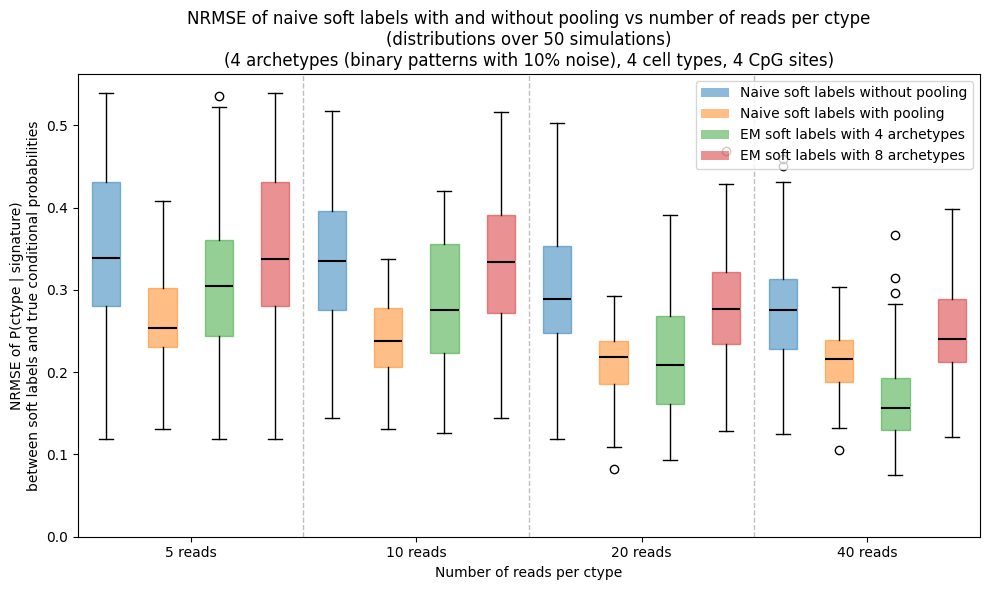

In [18]:
# box plots of the nrmse distributions for each method and each number of reads per sample
from matplotlib.patches import Patch

method_colors = {
    "no_pooling": "#1f77b4",        # blue
    "pooling": "#ff7f0e",           # orange
    "archetypes": "#2ca02c",        # green
    "archetypes_2x": "#d62728",     # red
}

plt.figure(figsize=(10, 6))

# Order boxes by read count first, then method
method_specs = [
    ("no_pooling", "no pooling", nrmse_without_pooling),
    ("pooling", "pooling", nrmse_with_pooling),
    ("archetypes", f"{n_ctypes} archetypes", nrmse_with_archetypes),
    ("archetypes_2x", f"{2 * n_ctypes} archetypes", nrmse_with_2x_archetypes),
]
n_methods = len(method_specs)

boxplot_data = []
box_colors = []
for i in range(n_setups):
    for method_key, _, method_values in method_specs:
        boxplot_data.append(method_values[i])
        box_colors.append(method_colors[method_key])

# Keep per-box labels empty; we add one centered label per read-count group below
bp = plt.boxplot(boxplot_data, tick_labels=[""] * len(boxplot_data), patch_artist=True)

for patch, color in zip(bp["boxes"], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)
    patch.set_edgecolor(color)
for median in bp["medians"]:
    median.set_color("black")
    median.set_linewidth(1.5)

# Vertical separators between read-count groups
for i in range(1, n_setups):
    plt.axvline(
        x=i * n_methods + 0.5,
        color="gray",
        linestyle="--",
        linewidth=1,
        alpha=0.5,
        zorder=0,
    )

# One x-tick label per group, centered on its 4 method boxes
group_centers = [
    i * n_methods + (n_methods + 1) / 2 for i in range(n_setups)
]
group_labels = [f"{n_reads} reads" for n_reads in n_reads_per_sample_grid]
plt.xticks(group_centers, group_labels, rotation=0)

legend_handles = [
    Patch(facecolor=method_colors["no_pooling"], alpha=0.5, label="Naive soft labels without pooling"),
    Patch(facecolor=method_colors["pooling"], alpha=0.5, label="Naive soft labels with pooling"),
    Patch(facecolor=method_colors["archetypes"], alpha=0.5, label=f"EM soft labels with {n_ctypes} archetypes"),
    Patch(facecolor=method_colors["archetypes_2x"], alpha=0.5, label=f"EM soft labels with {2 * n_ctypes} archetypes"),
]
plt.legend(handles=legend_handles, loc="upper right")

plt.ylabel(
    "NRMSE of P(ctype | signature)\nbetween soft labels and true conditional probabilities"
)
plt.xlabel("Number of reads per ctype")
plt.title(
    "NRMSE of naive soft labels with and without pooling vs number of reads per ctype\n"
    f"(distributions over {N_SIMULATIONS} simulations)\n"
    f"({n_ctypes} archetypes (binary patterns with 10% noise), {n_ctypes} cell types, 4 CpG sites)"
)
plt.ylim(0, None)
plt.tight_layout()
plt.show()

## Experiment 3: unknown ctype proportions

## Experiment X: low per sample coverage and pooling of counts

We use realistic coverage and fractions.

In [ ]:
# THIS EXPERIMENT IS DISCONTINUED FOR NOW
assert False, "End of code snippet"

In [ ]:
N_CTYPES = 2
signatures = np.array(
    [
        [0, 0, 0, 0],
        [0, 0, 0, 1],
        [0, 0, 1, 0],
        [0, 0, 1, 1],
        [0, 1, 0, 0],
        [0, 1, 0, 1],
        [0, 1, 1, 0],
        [0, 1, 1, 1],
        [1, 0, 0, 0],
        [1, 0, 0, 1],
        [1, 0, 1, 0],
        [1, 0, 1, 1],
        [1, 1, 0, 0],
        [1, 1, 0, 1],
        [1, 1, 1, 0],
        [1, 1, 1, 1],
    ]
)
N_SIGNATURES = signatures.shape[0]

In [ ]:
N_SAMPLES = 8
ctype_proportions_per_sample = np.array(
    [
        [0.81, 0.19],  # tumor sample
        [0.69, 0.31],  # tumor sample
        [0.54, 0.46],  # tumor sample
        [0.95, 0.05],  # normal sample
        [0.97, 0.03],  # normal sample
        [0.98, 0.02],  # normal sample
        [0.98, 0.02],  # normal sample
        [0.97, 0.03],  # normal sample
    ]
)  # (n_samples, n_ctypes)
read_counts_per_sample = np.array([4, 7, 9, 7, 10, 6, 7, 7])  # (n_samples,)
scaling = 1
read_counts_per_sample *= scaling
cancer_weight_by_unmethylated_cpg = [20, 5, 3, 2.0, 0]
dummy_proportions = [
    cancer_weight_by_unmethylated_cpg[int(sig.sum())] for sig in signatures
]
dummy_proportions = np.array(dummy_proportions)
dummy_proportions /= dummy_proportions.sum()
signature_proportions_per_ctype = np.array(
    [
        dummy_proportions[::-1],  # ctype 0 (healthy, mostly methylated)
        dummy_proportions,  # ctype 1 (tumor, mostly unmethylated)
    ]
)  # (n_ctypes, n_signatures)

In [ ]:
for i in range(5):
    total = 0
    count = 0
    for j in range(N_SIGNATURES):
        if signatures[j].sum() == i:
            total += dummy_proportions[j]
            count += 1
    print(f"Sum {i}: mean {total/count:.2f}, count {count}")

In [ ]:
np.bincount(signatures.sum(axis=1), weights=dummy_proportions)

In [ ]:
# sample the signatures contents for each sample
ctype_counts_per_sample = np.array(
    [
        np.random.multinomial(
            read_counts_per_sample[i], ctype_proportions_per_sample[i]
        )
        for i in range(N_SAMPLES)
    ]
)
signature_counts_per_sample = np.array(
    [
        np.random.multinomial(
            ctype_counts_per_sample[i, 0], signature_proportions_per_ctype[0]
        )
        + np.random.multinomial(
            ctype_counts_per_sample[i, 1], signature_proportions_per_ctype[1]
        )
        for i in range(N_SAMPLES)
    ]
)
signature_proportions_per_sample = (
    signature_counts_per_sample / signature_counts_per_sample.sum(axis=1, keepdims=True)
)
print(signature_counts_per_sample)

In [ ]:
# print for each sample the number of signatures having 0, 1, 2, 3, or 4 unmethylated CpGs
for i in range(N_SAMPLES):
    print(f"Sample {i}:", end=" ")
    print(
        np.bincount(
            signatures.sum(axis=1), weights=signature_counts_per_sample[i]
        ).astype(int)
    )

In [ ]:
# naive pooling: pooling counts from all signatures at a distance of 1 CpG


def signature_distance(sig1, sig2):
    return np.sum(np.abs(sig1 - sig2))


pooled_signature_counts_per_sample = np.zeros((N_SAMPLES, N_SIGNATURES), dtype=int)
for i in range(N_SAMPLES):
    for j in range(N_SIGNATURES):
        for k in range(N_SIGNATURES):
            if signature_distance(signatures[j], signatures[k]) <= 1:
                pooled_signature_counts_per_sample[i, j] += signature_counts_per_sample[
                    i, k
                ]
pooled_signature_proportions_per_sample = (
    pooled_signature_counts_per_sample
    / pooled_signature_counts_per_sample.sum(axis=1, keepdims=True)
)

In [ ]:
# print for each sample the number of signatures having 0, 1, 2, 3, or 4 unmethylated CpGs
for i in range(N_SAMPLES):
    print(f"Sample {i}:", end=" ")
    print(
        np.bincount(
            signatures.sum(axis=1), weights=pooled_signature_counts_per_sample[i]
        ).astype(int)
    )

In [ ]:
signature_counts_per_sample

In [ ]:
# least squares
F = cp.Variable((N_CTYPES, N_SIGNATURES), nonneg=True)
objective = cp.Minimize(
    cp.sum_squares(ctype_proportions_per_sample @ F - signature_proportions_per_sample)
)
constraints = [cp.sum(F, axis=1) == 1]  # each row sums to 1
problem = cp.Problem(objective, constraints)
problem.solve()
F_solution = F.value
F_solution.round(2).T

In [ ]:
signature_proportions_per_ctype.round(2).T